In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt


In [19]:
np.random.seed(42)
#makes NumPy's random operations predictable and reproducible.
x, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

In [20]:
x.shape

(500, 2)

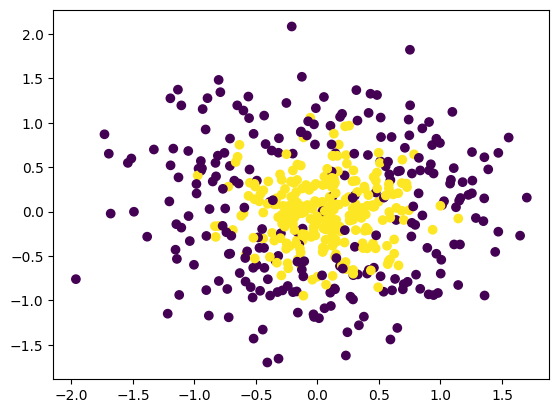

In [21]:
plt.scatter(x[:,0],x[:,1],c=y)

In [22]:
from sklearn.tree import DecisionTreeClassifier

In [23]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

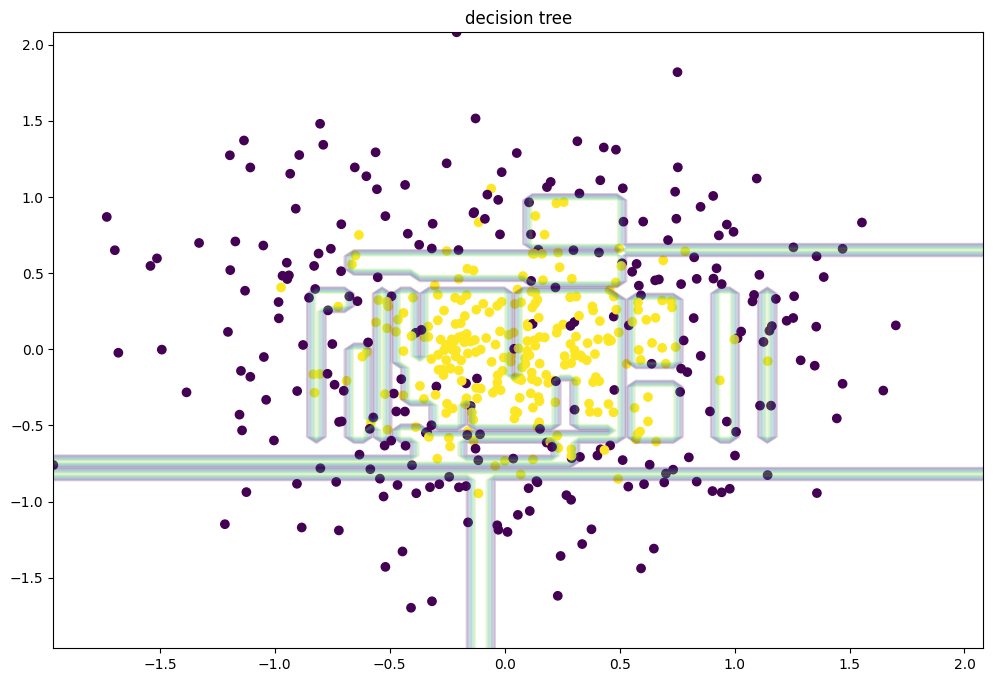

In [24]:
plt.figure(figsize=(12,8))
x_range = np.linspace(x.min(), x.max(),100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contour(xx1,xx2, y_hat, alpha=0.2)
plt.scatter(x[:,0],x[:,1],c=y, cmap ='viridis',alpha=1)
plt.title("decision tree")
plt.show()

In [25]:
from sklearn.ensemble import RandomForestClassifier

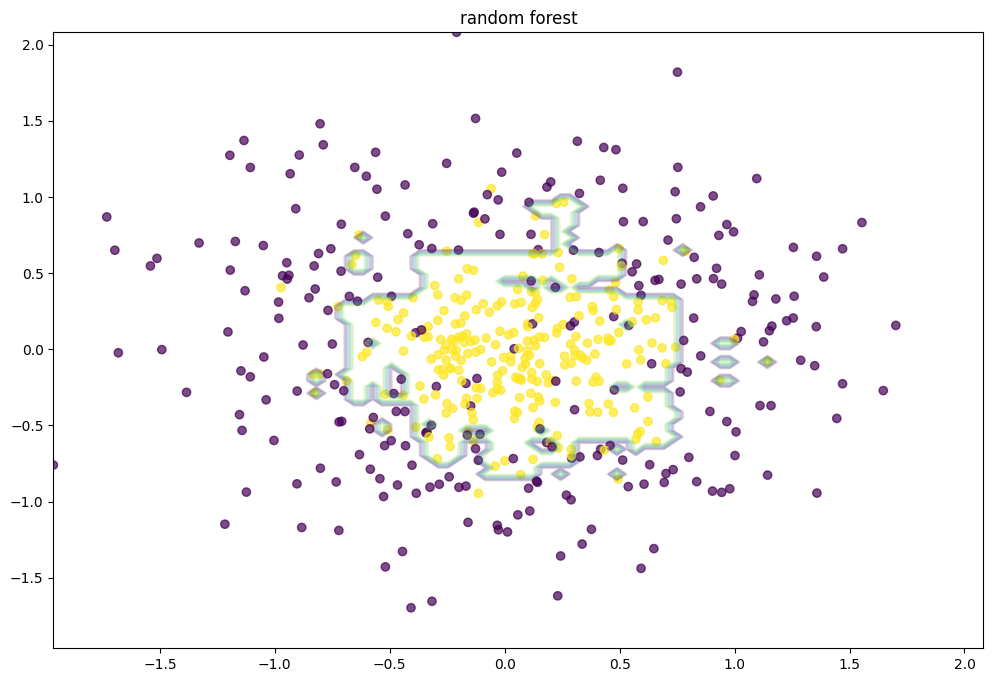

In [26]:
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(x_train,y_train)

plt.figure(figsize=(12,8))
x_range = np.linspace(x.min(), x.max(),100)
xx1,xx2 = np.meshgrid(x_range, x_range)
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contour(xx1,xx2, y_hat,alpha=0.2)
plt.scatter(x[:,0], x[:,1], c=y, cmap='viridis',alpha = .7)
plt.title("random forest")
plt.show()

In [27]:
n_train = 150
n_test = 1000
noise = 0.1

# generate data
def f(x):
  x = x.ravel()
  return np.exp(-x**2)+ 1.5 * np.exp(-(x-2) ** 2)


def generate(n_samples, noise):
  x = np.random.rand(n_samples) * 10 - 5
  x = np.sort(x).ravel()
  y = (
    np.exp(-x**2)
    + 1.5 * np.exp(-(x-2)**2)
    + np.random.normal(0.0, noise, n_samples)
)
  x = x.reshape((n_samples,1))

  return x,y

x_train, y_train = generate(n_samples = n_train, noise=noise)
x_test, y_test = generate(n_samples = n_test, noise = noise)


(-5.0, 5.0)

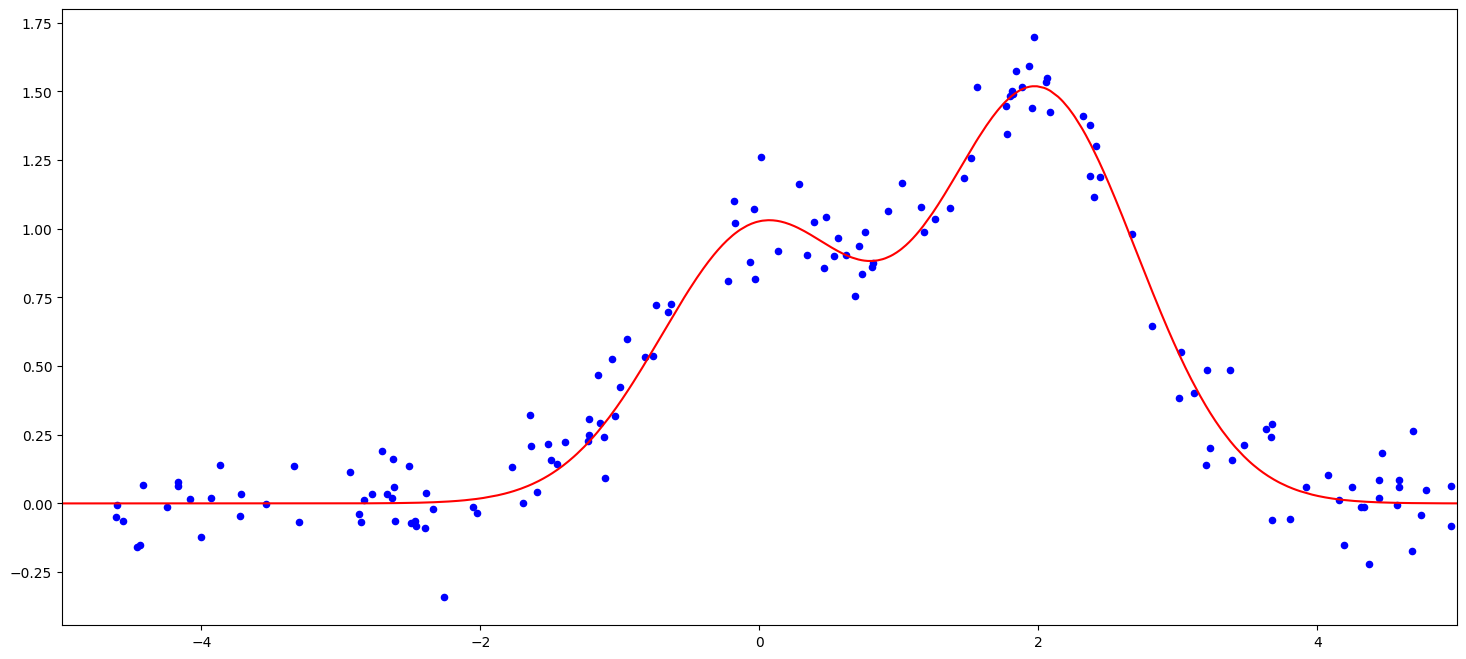

In [28]:
plt.figure(figsize = (18,8))
plt.plot(x_test, f(x_test),"r")
plt.scatter(x_train, y_train, c="b", s=20)
plt.xlim([-5,5])

Text(0.5, 1.0, 'Decision tree MSE = 22.70')

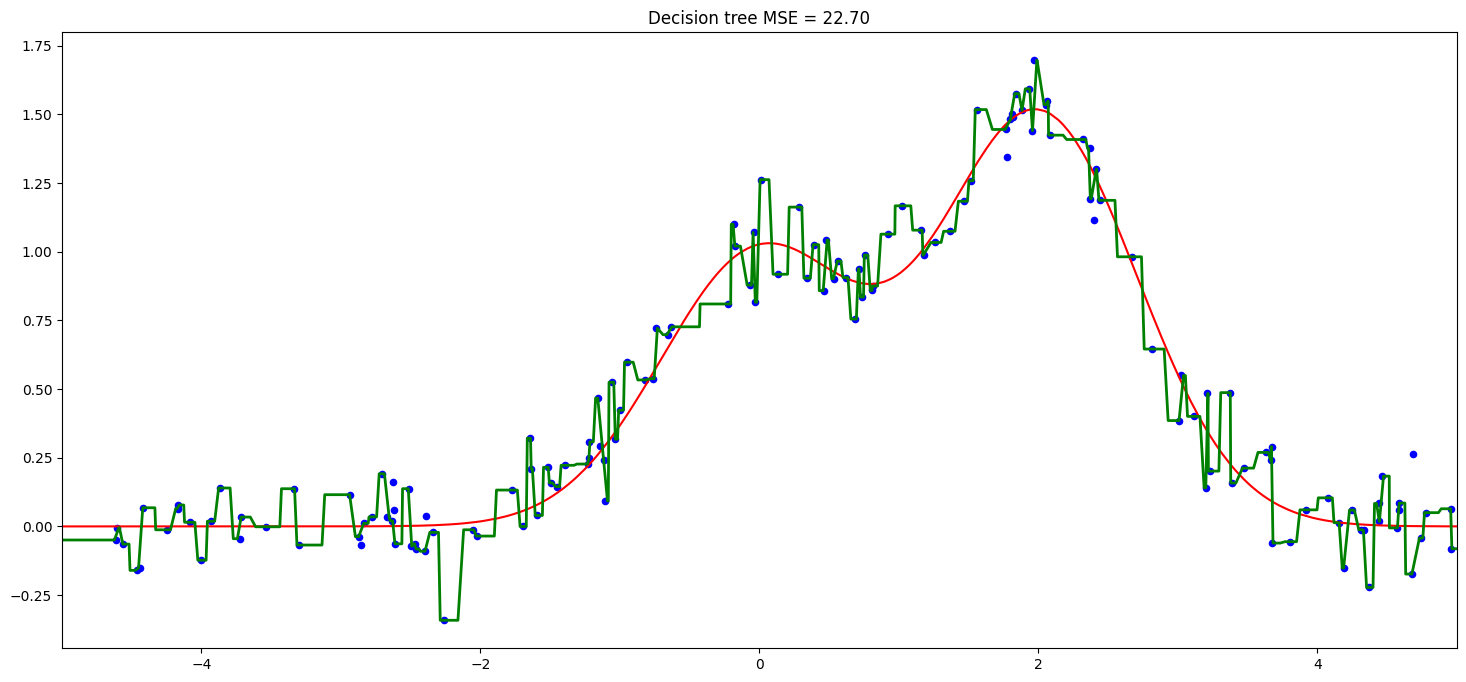

In [29]:
#one decision tree regressor
from sklearn.tree import DecisionTreeRegressor

dtree = DecisionTreeRegressor().fit(x_train, y_train)
d_predict = dtree.predict(x_test)

plt.figure(figsize=(18,8))
plt.plot(x_test, f(x_test),"r")
plt.scatter(x_train, y_train, c="b",s=20)
plt.plot(x_test, d_predict, "g",lw=2)
plt.xlim([-5,5])
plt.title("Decision tree MSE = %.2f" % np.sum((y_test-d_predict) ** 2))

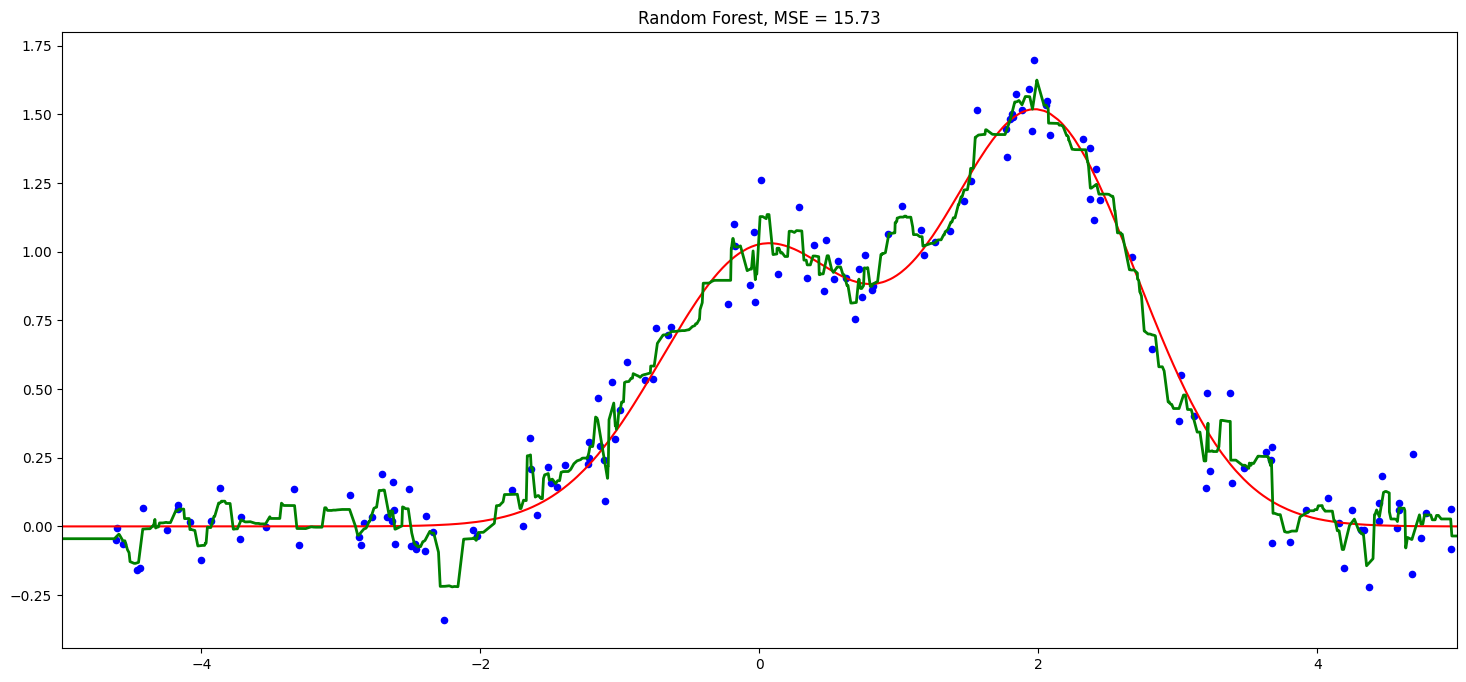

In [30]:
#random forest

from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators = 1000).fit(x_train,y_train)
rf_predict = rfr.predict(x_test)

plt.figure(figsize=(18,8))
plt.plot(x_test, f(x_test),"r")
plt.scatter(x_train, y_train, c="b",s=20)
plt.plot(x_test, rf_predict, "g",lw=2)
plt.xlim([-5,5])
plt.title("Random Forest, MSE = %.2f" % np.sum((y_test - rf_predict) ** 2));